In [10]:
# import

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")

RANDOM_STATE = 42

# Save all EDA figures under reports/figure/eda
FIG_DIR = Path("../reports/figures/eda")
FIG_DIR.mkdir(parents=True, exist_ok=True)
_eda_fig_counter = 0

def save_eda_fig(name: str | None = None):
    global _eda_fig_counter
    _eda_fig_counter += 1
    if name is None:
        name = f"eda_figure_{_eda_fig_counter:02d}"
    safe = "".join(ch.lower() if ch.isalnum() else "_" for ch in name).strip("_")
    out = FIG_DIR / f"{_eda_fig_counter:02d}_{safe}.png"
    plt.savefig(out, dpi=300, bbox_inches="tight")
    print(f"Saved: {out}")


In [11]:
# load data

DATA_PATH = "../data/raw/telco_customer_churn.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
print(df.shape)
print(df.dtypes)
print(df.head())

(7043, 21)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45    

              missing_count  missing_pct
TotalCharges             11         0.16
Saved: ../reports/figures/eda/01_missing_value_percentage_by_column.png


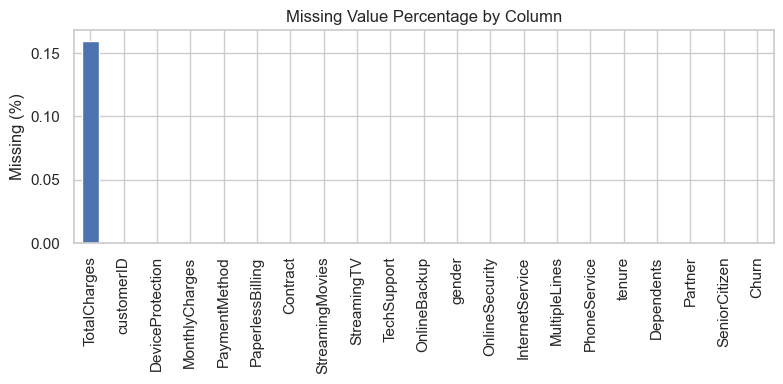

In [ ]:
# 2) Missing value analysis
# Hidden missing often appears as blank strings in TotalCharges
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Missing counts and percentages
miss = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100).round(2)
}).sort_values("missing_pct", ascending=False)

print(miss[miss["missing_count"] > 0])

# Visual missingness summary
plt.figure(figsize=(8, 4))
miss["missing_pct"].plot(kind="bar")
plt.ylabel("Missing (%)")
plt.title("Missing Value Percentage by Column")
plt.tight_layout()
save_eda_fig("missing_value_percentage_by_column")
plt.show()


       count    pct
Churn              
No      5174  73.46
Yes     1869  26.54
Saved: ../reports/figures/eda/02_class_distribution_churn.png


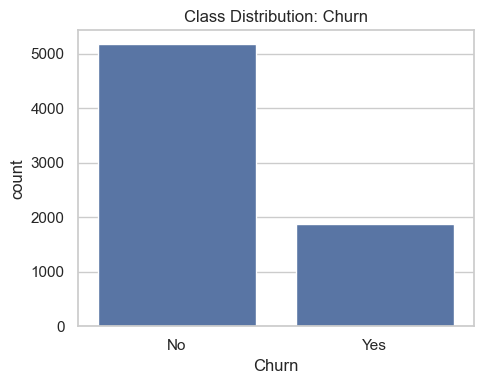

In [14]:
# 3) Class imbalance inspection (Churn)
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100
print(pd.concat([churn_counts, churn_pct.round(2)], axis=1, keys=["count", "pct"]))

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Churn", order=["No", "Yes"])
plt.title("Class Distribution: Churn")
plt.tight_layout()
save_eda_fig("class_distribution_churn")
plt.show()


Saved: ../reports/figures/eda/03_numerical_distributions_by_churn.png


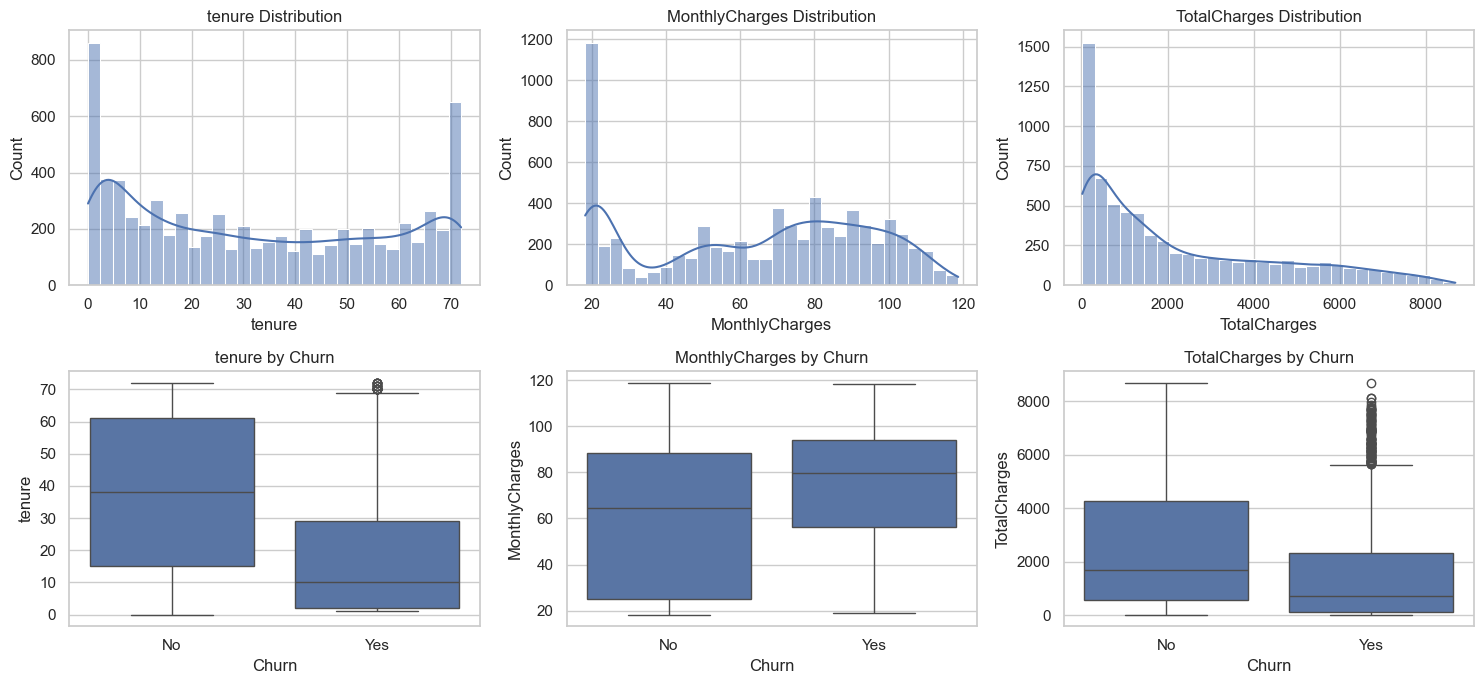

In [15]:
# 4) Distribution plots for key numerical variables
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(2, len(num_cols), figsize=(15, 7))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[0, i], bins=30)
    axes[0, i].set_title(f"{col} Distribution")
    
    sns.boxplot(data=df, x="Churn", y=col, order=["No", "Yes"], ax=axes[1, i])
    axes[1, i].set_title(f"{col} by Churn")

plt.tight_layout()
save_eda_fig("numerical_distributions_by_churn")
plt.show()


Saved: ../reports/figures/eda/04_churn_pct_by_contract.png


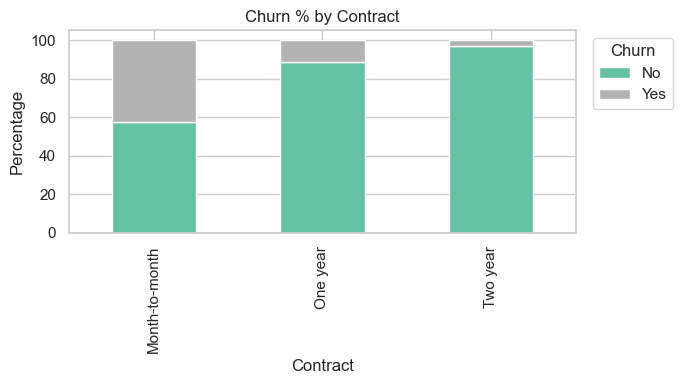

Saved: ../reports/figures/eda/05_counts_contract_vs_churn.png


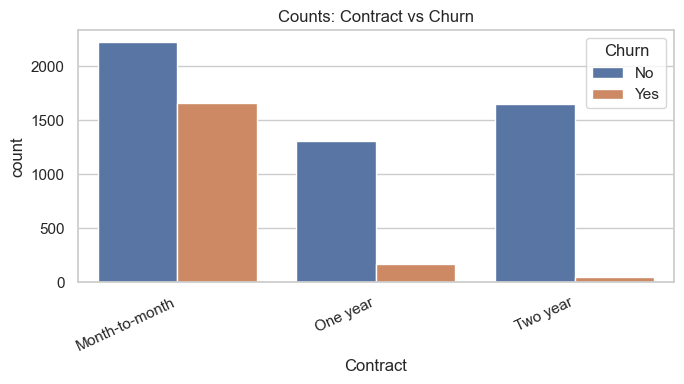

Saved: ../reports/figures/eda/06_churn_pct_by_internetservice.png


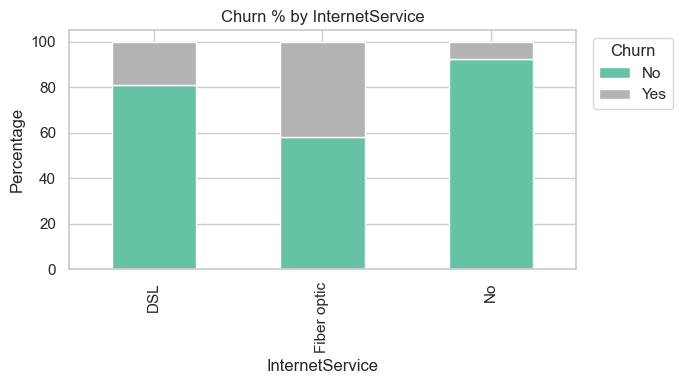

Saved: ../reports/figures/eda/07_counts_internetservice_vs_churn.png


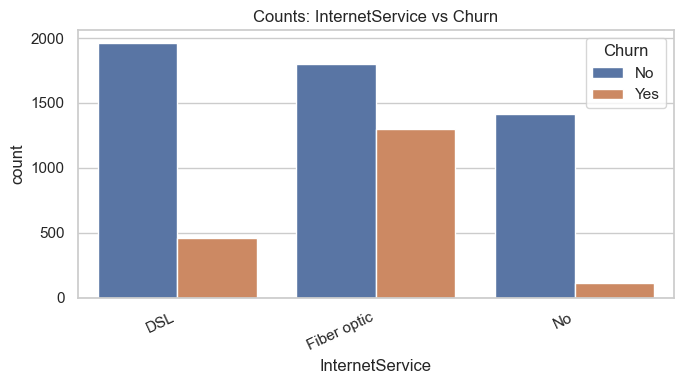

Saved: ../reports/figures/eda/08_churn_pct_by_paymentmethod.png


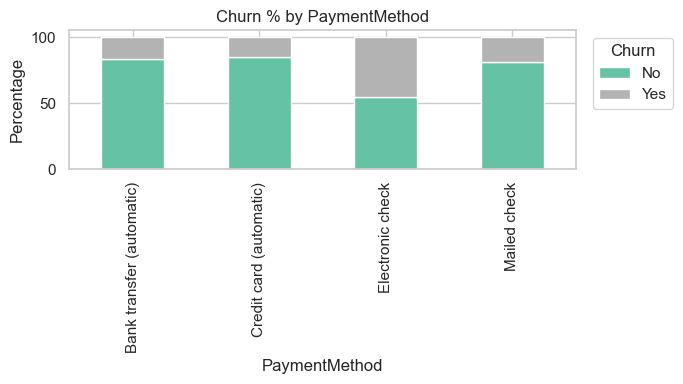

Saved: ../reports/figures/eda/09_counts_paymentmethod_vs_churn.png


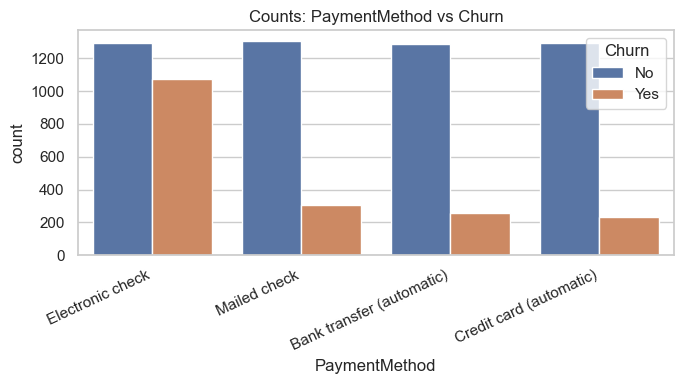

Saved: ../reports/figures/eda/10_churn_pct_by_paperlessbilling.png


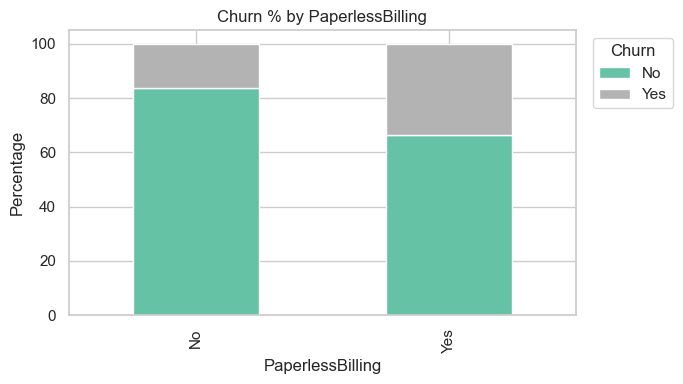

Saved: ../reports/figures/eda/11_counts_paperlessbilling_vs_churn.png


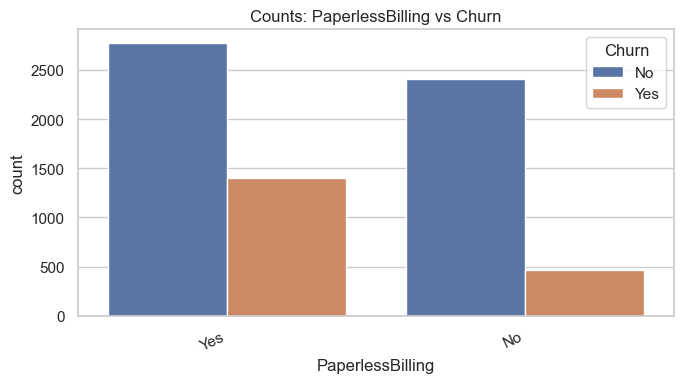

In [16]:
#5) Categorical vs churn comparisons (rate + count)

cat_cols = ["Contract", "InternetService", "PaymentMethod", "PaperlessBilling"]

for col in cat_cols:
    ct = pd.crosstab(df[col], df["Churn"], normalize="index").mul(100)
    ct = ct[["No", "Yes"]] if {"No", "Yes"}.issubset(ct.columns) else ct
    
    ax = ct.plot(kind="bar", stacked=True, figsize=(7, 4), colormap="Set2")
    plt.title(f"Churn % by {col}")
    plt.ylabel("Percentage")
    plt.legend(title="Churn", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    save_eda_fig(f"churn_pct_by_{col}")
    plt.show()

    # Optional: raw counts
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col, hue="Churn")
    plt.title(f"Counts: {col} vs Churn")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    save_eda_fig(f"counts_{col}_vs_churn")
    plt.show()


6) Potential leakage indicators to inspect early
Practical checks:

ID-like columns (customerID) that should be excluded from modeling.
Variables that may encode future/post-outcome information (in other datasets).
Suspiciously high target correlation/perfect separation.
Time-proxy variables requiring strict prediction timestamp assumptions (tenure, TotalCharges).

In [17]:
# 1) ID columns
id_like = [c for c in df.columns if "id" in c.lower()]
print("ID-like columns:", id_like)

# 2) Very high-cardinality categorical columns (possible identifiers/proxies)
high_card = df.select_dtypes(include="object").nunique().sort_values(ascending=False)
print("High-cardinality categorical features:\n", high_card.head(10))

# 3) Numeric association with target (quick screen)
tmp = df.copy()
tmp["Churn_bin"] = (tmp["Churn"] == "Yes").astype(int)
num_corr = tmp.select_dtypes(include=np.number).corr()["Churn_bin"].sort_values(ascending=False)
print("Correlation with Churn_bin:\n", num_corr)

# 4) Near-perfect separation check for categorical levels
for col in df.select_dtypes(include="object").columns:
    if col == "Churn":
        continue
    rates = pd.crosstab(df[col], df["Churn"], normalize="index")
    if "Yes" in rates.columns:
        extreme = rates[(rates["Yes"] < 0.01) | (rates["Yes"] > 0.99)]
        if not extreme.empty:
            print(f"\nPotential leakage/perfect-separation signal in: {col}")
            print(extreme.head())

ID-like columns: ['customerID']
High-cardinality categorical features:
 customerID          7043
PaymentMethod          4
DeviceProtection       3
Contract               3
StreamingMovies        3
StreamingTV            3
TechSupport            3
OnlineBackup           3
OnlineSecurity         3
InternetService        3
dtype: int64
Correlation with Churn_bin:
 Churn_bin         1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.199484
tenure           -0.352229
Name: Churn_bin, dtype: float64

Potential leakage/perfect-separation signal in: customerID
Churn        No  Yes
customerID          
0002-ORFBO  1.0  0.0
0003-MKNFE  1.0  0.0
0004-TLHLJ  0.0  1.0
0011-IGKFF  0.0  1.0
0013-EXCHZ  0.0  1.0


/var/folders/p3/s92f8yws04706z7jzqxc52qr0000gn/T/ipykernel_94713/1920435687.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  high_card = df.select_dtypes(include="object").nunique().sort_values(ascending=False)
/var/folders/p3/s92f8yws04706z7jzqxc52qr0000gn/T/ipykernel_94713/1920435687.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silenc

Suggested EDA output for report
1 table: missingness summary.
1 figure: class imbalance.
1 panel: numeric distributions + churn-wise boxplots.
3–4 stacked bar charts: strongest categorical drivers.
1 short subsection: leakage screening findings and actions (drop customerID, enforce prediction-time feature availability).